<a href="https://colab.research.google.com/github/nguyendangcole/assignment-P4AI/blob/main/P4D%26Ai_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mmuneeb5522/crossplatform-trending-topics-2026multilanguage")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crossplatform-trending-topics-2026multilanguage' dataset.
Path to dataset files: /kaggle/input/crossplatform-trending-topics-2026multilanguage


In [ ]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path,"trending_topics_2026_synthetic.csv"))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2500 non-null   object 
 1   date               2500 non-null   object 
 2   source             2500 non-null   object 
 3   language           2500 non-null   object 
 4   country            2500 non-null   object 
 5   topic_category     2500 non-null   object 
 6   topic_subcategory  2500 non-null   object 
 7   headline           2500 non-null   object 
 8   short_text         2500 non-null   object 
 9   sentiment          2500 non-null   object 
 10  engagement_score   2500 non-null   int64  
 11  trend_score        2500 non-null   float64
dtypes: float64(1), int64(1), object(10)
memory usage: 234.5+ KB


In [ ]:
df = df.dropna(subset=['short_text'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2500 non-null   object 
 1   date               2500 non-null   object 
 2   source             2500 non-null   object 
 3   language           2500 non-null   object 
 4   country            2500 non-null   object 
 5   topic_category     2500 non-null   object 
 6   topic_subcategory  2500 non-null   object 
 7   headline           2500 non-null   object 
 8   short_text         2500 non-null   object 
 9   sentiment          2500 non-null   object 
 10  engagement_score   2500 non-null   int64  
 11  trend_score        2500 non-null   float64
dtypes: float64(1), int64(1), object(10)
memory usage: 234.5+ KB


# **Dataset Overview**

In [ ]:
import pandas as pd

# Giả sử file của bạn là 'dataset.csv' với cột nội dung là 'text' và nhãn là 'category'


# 1. Total Articles (Tổng số bài viết)
total_articles = len(df)

# 2. Categories (Số lượng danh mục/nhãn)
num_categories = df['topic_category'].nunique()

# Tính toán số từ và số ký tự cho mỗi bài
df['word_count'] = df['short_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['short_text'].apply(lambda x: len(str(x)))

# 3. Avg Words/Article (Trung bình số từ)
avg_words = df['word_count'].mean()

# 4. Avg Chars/Article (Trung bình số ký tự)
avg_chars = df['char_count'].mean()

print(f"Total Articles: {total_articles}")
print(f"Categories: {num_categories}")
print(f"Avg Words: {avg_words:.0f}")
print(f"Avg Chars: {avg_chars:.0f}")

Total Articles: 2500
Categories: 5
Avg Words: 17
Avg Chars: 116


# **Category Distribution**

In [ ]:
# Load data from URL or upload
import pandas as pd
import plotly.graph_objects as go



# Option 2: Upload in Google Colab
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('bbc-news.csv')

# Count articles per category
category_counts = df['topic_category'].value_counts().sort_index()

# Create pie chart
fig1 = go.Figure(data=[go.Pie(
    labels=category_counts.index,
    values=category_counts.values,
    hole=0.3,  # Makes it a donut chart
    marker=dict(colors=['#667eea', '#764ba2', '#f093fb', '#4facfe', '#43e97b']),
    textinfo='label+percent',
    textfont_size=14
)])

fig1.update_layout(
    title='Category Distribution',
    showlegend=True,
    width=600,
    height=400
)

fig1.show()

# Print statistics
print("Category Distribution:")
print(category_counts)
print(f"\nTotal articles: {len(df)}")
print(f"Most common: {category_counts.idxmax()} ({category_counts.max()} articles)")
print(f"Least common: {category_counts.idxmin()} ({category_counts.min()} articles)")

Category Distribution:
topic_category
ai_and_tech      507
economy          492
entertainment    511
global_events    544
sports           446
Name: count, dtype: int64

Total articles: 2500
Most common: global_events (544 articles)
Least common: sports (446 articles)


In [ ]:
fig1.write_html("my_graph.html")

# Stop Words Analysis

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Count stop words
all_words = ' '.join(df['short_text']).lower().split()
stop_word_counts = Counter([word for word in all_words if word in stop_words])
top_stop_words = stop_word_counts.most_common(20)

words = [word for word, count in top_stop_words]
counts = [count for word, count in top_stop_words]

# Create bar chart
fig2 = go.Figure(data=[go.Bar(
    x=words,
    y=counts,
    marker_color='#764ba2',
    text=counts,
    textposition='outside'
)])

fig.update_layout(
    title='Top 20 Stop Words',
    xaxis_title='Stop Words',
    yaxis_title='Frequency',
    width=900,
    height=400,
    showlegend=False
)

fig.show()

# Statistics
total_words = len(all_words)
total_stop_words = sum(stop_word_counts.values())
print(f"Total words: {total_words:,}")
print(f"Stop words: {total_stop_words:,} ({total_stop_words/total_words*100:.1f}%)")
print(f"Unique stop words found: {len(stop_word_counts)}")

Total words: 42,184
Stop words: 16,778 (39.8%)
Unique stop words found: 9


In [ ]:
fig2.write_html("S_W_S.html")

# **Word Count Distribution**

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

df['word_count'] = df['short_text'].str.split().str.len().fillna(0).astype(int)


max_range = 21
bins = np.arange(0, max_range + 1, 1)

hist, bin_edges = np.histogram(df['word_count'], bins=bins)

bin_labels = [str(int(bin_edges[i])) for i in range(len(hist))]

fig = go.Figure(data=[go.Bar(
    x=bin_labels,
    y=hist,
    marker_color='#667eea',
    text=hist,
    textposition='outside'
)])

fig.update_layout(
    title='Phân phối chi tiết số lượng từ (Từ 0 đến 20 từ)',
    xaxis_title='Số lượng từ chính xác (Exact Word Count)',
    yaxis_title='Số lượng bài viết',
    width=1000, # Tăng chiều rộng để các con số không bị dính nhau
    height=500,
    template='plotly_white',
    xaxis=dict(
        type='category', # Ép kiểu category để hiện đủ các số 0, 1, 2...
        tickmode='linear'
    )
)

fig.show()

# Xuất file để bạn đẩy lên web
fig.write_html("detailed_word_count_0_20.html")

# Thống kê nhanh cho nhóm nhỏ này
print(f"Tổng số bài viết có từ 0-20 từ: {sum(hist)}")

Tổng số bài viết có từ 0-20 từ: 2500


# **Character Count Distribution**

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Calculate character counts
df['char_count'] = df['short_text'].str.len()

# Create histogram bins
bins = np.arange(100, df['char_count'].max() + 1, 1)
hist, bin_edges = np.histogram(df['char_count'], bins=bins)

bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(hist))]

# Create histogram
fig = go.Figure(data=[go.Bar(
    x=bin_labels,
    y=hist,
    marker_color='#f093fb',
    text=hist,
    textposition='outside'
)])

fig.update_layout(
    title='Character Count Distribution',
    xaxis_title='Character Count Ranges',
    yaxis_title='Number of Articles',
    width=900,
    height=400,
    showlegend=False,
    xaxis={'tickangle': 45}
)

fig.show()
fig.write_html("C_C_D")

# Print statistics
print(f"Mean: {df['char_count'].mean():.2f}")
print(f"Median: {df['char_count'].median():.2f}")
print(f"Min: {df['char_count'].min()}")
print(f"Max: {df['char_count'].max()}")

# Estimate average word length
avg_word_length = df['char_count'].sum() / df['short_text'].str.split().str.len().sum()
print(f"\nAverage word length: {avg_word_length:.2f} characters")

Mean: 115.78
Median: 116.00
Min: 108
Max: 124

Average word length: 6.86 characters


Vocabulary richness by categories
    words = re.findall(r'\b[a-z]{3,}\b', all_text)


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Calculate vocabulary richness per category
vocab_stats = []
for category in sorted(df['topic_category'].unique()):
    cat_df = df[df['topic_category'] == category]

    # Get all words, remove stop words
    import re
    all_text = ' '.join(cat_df['short_text']).lower()
    # Use regex to match words >= 3 characters (same as report)
    words = re.findall(r'\b[a-z]{3,}\b', all_text)
    words = [w for w in words if w not in stop_words]

    unique_words = len(set(words))
    total_words = len(words)
    ttr = unique_words / total_words if total_words > 0 else 0

    vocab_stats.append({
        'category': category,
        'unique_words': unique_words,
        'total_words': total_words,
        'ttr': ttr,
        'articles': len(cat_df)
    })

vocab_df = pd.DataFrame(vocab_stats)

# Create bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=vocab_df['category'],
    y=vocab_df['unique_words'],
    name='Unique Words',
    marker_color='#4facfe'
))

fig.update_layout(
    title='Vocabulary Richness by Category',
    xaxis_title='Category',
    yaxis_title='Unique Words Count',
    width=800,
    height=400
)

fig.show()
fig.write_html("V_R_b_C")

# Print statistics
print("\nVocabulary Richness Statistics:")
print(vocab_df.to_string(index=False))


Vocabulary Richness Statistics:
     category  unique_words  total_words      ttr  articles
  ai_and_tech            13         4680 0.002778       507
      economy            13         4554 0.002855       492
entertainment            13         4725 0.002751       511
global_events            13         5440 0.002390       544
       sports            12         4014 0.002990       446


TOP 50 WORDS BY CATEGORIES

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select a category to analyze
category = 'economy'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Get word frequencies (remove stop words)
import re

all_text = ' '.join(cat_df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(20)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=counts_list,
    y=words_list,
    orientation='h',
    marker_color='#667eea',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 Words in {category.capitalize()} Articles',
    xaxis_title='Frequency',
    yaxis_title='Words',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}  # Top word at top
)

fig.show()
fig.write_html("20_words_economy")
# Print statistics
print(f"\nTop words in {category}:")
for word, count in word_counts[:10]:
    print(f"  {word:15s}: {count:4d}")


Top words in economy:
  users          :  492
  actively       :  492
  discussing     :  492
  broader        :  492
  category       :  492
  economy        :  492
  multiple       :  492
  platforms      :  492
  inflation      :  127
  stock          :  126


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select a category to analyze
category = 'entertainment'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Get word frequencies (remove stop words)
import re

all_text = ' '.join(cat_df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(20)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=counts_list,
    y=words_list,
    orientation='h',
    marker_color='#667eea',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 Words in {category.capitalize()} Articles',
    xaxis_title='Frequency',
    yaxis_title='Words',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}  # Top word at top
)

fig.show()
fig.write_html("20_words_entertainment")
# Print statistics
print(f"\nTop words in {category}:")
for word, count in word_counts[:10]:
    print(f"  {word:15s}: {count:4d}")


Top words in entertainment:
  users          :  511
  actively       :  511
  discussing     :  511
  broader        :  511
  category       :  511
  entertainment  :  511
  multiple       :  511
  platforms      :  511
  hollywood      :  141
  kdrama         :  136


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select a category to analyze
category = 'global_events'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Get word frequencies (remove stop words)
import re

all_text = ' '.join(cat_df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(20)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=counts_list,
    y=words_list,
    orientation='h',
    marker_color='#667eea',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 Words in {category.capitalize()} Articles',
    xaxis_title='Frequency',
    yaxis_title='Words',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}  # Top word at top
)

fig.show()
fig.write_html("20_words_global_events")
# Print statistics
print(f"\nTop words in {category}:")
for word, count in word_counts[:10]:
    print(f"  {word:15s}: {count:4d}")


Top words in global_events:
  users          :  544
  actively       :  544
  discussing     :  544
  broader        :  544
  category       :  544
  global         :  544
  events         :  544
  multiple       :  544
  platforms      :  544
  elections      :  141


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select a category to analyze
category = 'ai_and_tech'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Get word frequencies (remove stop words)
import re

all_text = ' '.join(cat_df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(20)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=counts_list,
    y=words_list,
    orientation='h',
    marker_color='#667eea',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 Words in {category.capitalize()} Articles',
    xaxis_title='Frequency',
    yaxis_title='Words',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}  # Top word at top
)

fig.show()
fig.write_html("20_words_ai_and_tech")
# Print statistics
print(f"\nTop words in {category}:")
for word, count in word_counts[:10]:
    print(f"  {word:15s}: {count:4d}")


Top words in ai_and_tech:
  users          :  507
  actively       :  507
  discussing     :  507
  broader        :  507
  category       :  507
  tech           :  507
  multiple       :  507
  platforms      :  507
  startups       :  133
  agentic        :  131


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select a category to analyze
category = 'sports'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Get word frequencies (remove stop words)
import re

all_text = ' '.join(cat_df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(20)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=counts_list,
    y=words_list,
    orientation='h',
    marker_color='#667eea',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 Words in {category.capitalize()} Articles',
    xaxis_title='Frequency',
    yaxis_title='Words',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}  # Top word at top
)

fig.show()
fig.write_html("20_words_Sports")
# Print statistics
print(f"\nTop words in {category}:")
for word, count in word_counts[:10]:
    print(f"  {word:15s}: {count:4d}")


Top words in sports:
  users          :  446
  actively       :  446
  discussing     :  446
  broader        :  446
  category       :  446
  sports         :  446
  multiple       :  446
  platforms      :  446
  football       :  125
  esports        :  111


TOP 50 WORDS BUY CATEGORIES USING PLOTLY

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)


# Select a category to analyze
category = 'economy'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Get word frequencies (remove stop words)
import re

all_text = ' '.join(cat_df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(20)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=counts_list,
    y=words_list,
    orientation='h',
    marker_color='#667eea',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 Words in {category.capitalize()} Articles',
    xaxis_title='Frequency',
    yaxis_title='Words',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}  # Top word at top
)

fig.show()

# Print statistics
print(f"\nTop words in {category}:")
for word, count in word_counts[:10]:
    print(f"  {word:15s}: {count:4d}")


Top words in economy:
  users          :  492
  actively       :  492
  discussing     :  492
  broader        :  492
  category       :  492
  economy        :  492
  multiple       :  492
  platforms      :  492
  inflation      :  127
  stock          :  126


TOP 50 WORDS BY TERM

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import numpy as np



# Setup stopwords (same as web report)
stop_words = set(ENGLISH_STOP_WORDS)
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select category
category = 'economy'  # Change to: business, entertainment, politics, sport, tech

# Calculate TF-IDF on ALL documents in dataset (same as report)
vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(df['short_text'])
feature_names = vectorizer.get_feature_names_out()

# Get indices of documents in selected category
cat_indices = df[df['topic_category'] == category].index

# Get TF-IDF scores for documents in this category
cat_tfidf = tfidf_matrix[cat_indices]

# Calculate MEAN TF-IDF score for each term (same as report)
mean_scores = np.array(cat_tfidf.mean(axis=0)).flatten()

# Get top 20 terms
top_indices = mean_scores.argsort()[-20:][::-1]
top_words = [feature_names[i] for i in top_indices]
top_scores = [mean_scores[i] for i in top_indices]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=top_scores,
    y=top_words,
    orientation='h',
    marker_color='#764ba2',
    text=[f'{score:.4f}' for score in top_scores],
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 20 TF-IDF Terms in {category.capitalize()}',
    xaxis_title='TF-IDF Score',
    yaxis_title='Terms',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'}
)

fig.show()
fig.write_html("20_terms")
# Print top terms
print(f"\nTop TF-IDF terms in {category}:")
for word, score in zip(top_words[:10], top_scores[:10]):
    print(f"  {word:20s}: {score:.4f}")


Top TF-IDF terms in economy:
  economy             : 0.4463
  inflation           : 0.1798
  crypto              : 0.1775
  platforms           : 0.1701
  users               : 0.1701
  broader             : 0.1701
  actively            : 0.1701
  discussing          : 0.1701
  multiple            : 0.1701
  category            : 0.1701


N-gram Analysis (Bigrams)

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import numpy as np


# Setup stopwords (same as web report)
stop_words = set(ENGLISH_STOP_WORDS)
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Select category
category = 'economy'  # Change to: business, entertainment, politics, sport, tech
cat_df = df[df['topic_category'] == category]

# Combine all articles in category into ONE text (same as report)
combined_text = ' '.join(cat_df['short_text'].values)

# Extract bigrams using TF-IDF on the combined text
vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),  # Bigrams only
    max_features=50,
    stop_words=list(stop_words)
)
# Fit on single combined text (returns 1 row)
tfidf_matrix = vectorizer.fit_transform([combined_text])

# Get TF-IDF scores (single row, so no need for mean)
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray()[0]

# Get top 15 bigrams
top_indices = tfidf_scores.argsort()[-15:][::-1]
top_bigrams = [feature_names[i] for i in top_indices]
top_scores = [tfidf_scores[i] for i in top_indices]

# Create horizontal bar chart
fig = go.Figure(data=[go.Bar(
    x=top_scores,
    y=top_bigrams,
    orientation='h',
    marker_color='#4facfe',
    text=[f'{score:.4f}' for score in top_scores],
    textposition='outside'
)])

fig.update_layout(
    title=f'Top 15 Bigrams in {category.capitalize()} (TF-IDF)',
    xaxis_title='TF-IDF Score',
    yaxis_title='Bigrams',
    width=900,
    height=600,
    yaxis={'autorange': 'reversed'}
)

fig.show()

# Print results
print(f"\nTop bigrams in {category}:")
for bigram, score in zip(top_bigrams[:10], top_scores[:10]):
    print(f"  {bigram:25s}: {score:.4f}")


Top bigrams in economy:
  broader category         : 0.3762
  actively discussing      : 0.3762
  economy multiple         : 0.3762
  multiple platforms       : 0.3762
  category economy         : 0.3762
  platforms users          : 0.3755
  users actively           : 0.1759
  users pk                 : 0.1032
  pk actively              : 0.1032
  users gb                 : 0.0971


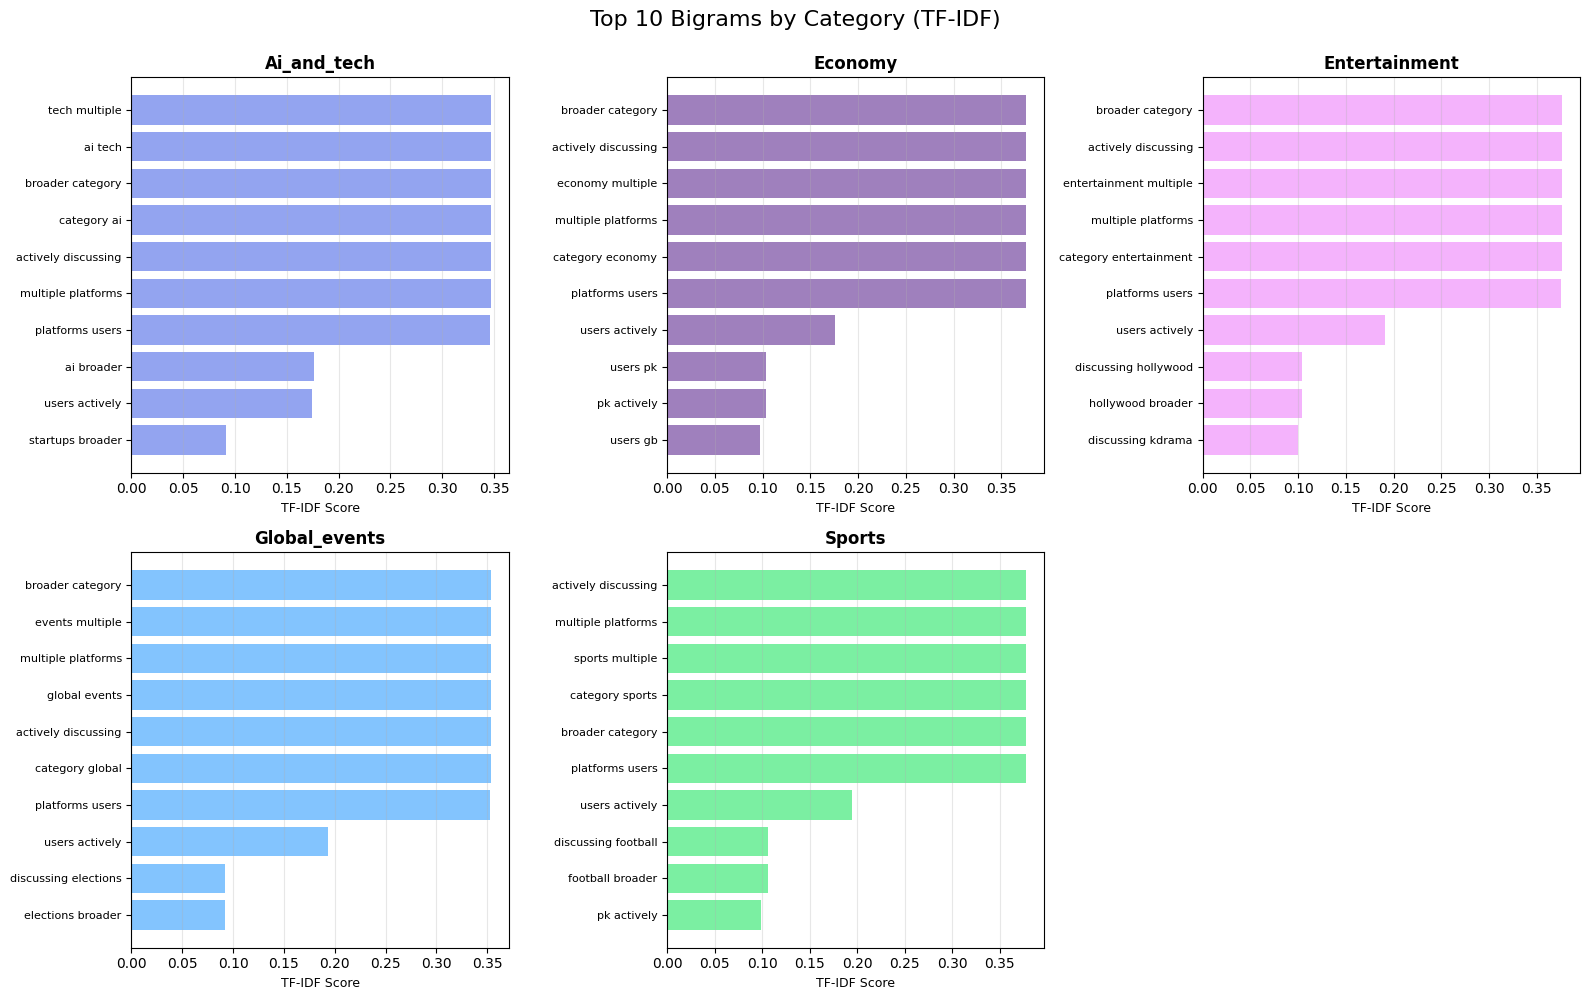

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import numpy as np



# Setup stopwords (same as web report)
stop_words = set(ENGLISH_STOP_WORDS)
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Analyze all categories
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Top 10 Bigrams by Category (TF-IDF)', fontsize=16, y=0.995)

categories = sorted(df['topic_category'].unique())
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe', '#43e97b']

for idx, category in enumerate(categories):
    ax = axes[idx // 3, idx % 3]

    # Extract bigrams for this category
    cat_df = df[df['topic_category'] == category]
    # Combine all articles into one text (same as report)
    combined_text = ' '.join(cat_df['short_text'].values)

    vectorizer = TfidfVectorizer(
        ngram_range=(2, 2),
        max_features=30,
        stop_words=list(stop_words)
    )
    # Fit on single combined text
    tfidf_matrix = vectorizer.fit_transform([combined_text])

    # Get scores (single row)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]

    # Get top 10
    top_indices = tfidf_scores.argsort()[-10:][::-1]
    top_bigrams = [feature_names[i] for i in top_indices]
    top_scores = [tfidf_scores[i] for i in top_indices]

    # Plot
    ax.barh(top_bigrams, top_scores, color=colors[idx], alpha=0.7)
    ax.set_title(category.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF Score', fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

Category Similarity Matrix

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# Setup stopwords (same as web report)
stop_words = set(ENGLISH_STOP_WORDS)
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Calculate TF-IDF on ALL documents (not combined per category)
categories = sorted(df['topic_category'].unique())
vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(df['short_text'])

# Calculate mean similarity between each pair of categories
n_cats = len(categories)
similarity_matrix = np.zeros((n_cats, n_cats))

for i, cat1 in enumerate(categories):
    cat1_indices = df[df['topic_category'] == cat1].index
    cat1_vectors = tfidf_matrix[cat1_indices]

    for j, cat2 in enumerate(categories):
        cat2_indices = df[df['topic_category'] == cat2].index
        cat2_vectors = tfidf_matrix[cat2_indices]

        # Compute pairwise similarities between all document pairs
        pairwise_sim = cosine_similarity(cat1_vectors, cat2_vectors)

        # Take mean similarity (this is why diagonal != 1.0)
        similarity_matrix[i, j] = np.mean(pairwise_sim)

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=similarity_matrix,
    x=categories,
    y=categories,
    colorscale='Purples',
    text=similarity_matrix,
    texttemplate='%{text:.3f}',
    textfont={"size": 12},
    colorbar=dict(title="Similarity")
))

fig.update_layout(
    title='Category Similarity Matrix (Cosine Similarity)',
    xaxis_title='Category',
    yaxis_title='Category',
    width=700,
    height=600,
    yaxis={'autorange': 'reversed'}
)

fig.show()

# Print similarity matrix
print("\nCategory Similarity Matrix:")
print("Note: Diagonal is NOT 1.0 because it's MEAN similarity between documents")
print("within same category, not self-similarity\n")

for i, cat1 in enumerate(categories):
    print(f"{cat1:15s}: {similarity_matrix[i][i]:.3f} (within-category)")
    for j, cat2 in enumerate(categories):
        if i < j:  # Cross-category only
            sim = similarity_matrix[i][j]
            status = "⚠️ High" if sim > 0.02 else "✓ Low"
            print(f"  vs {cat2:15s}: {sim:.3f} {status}")


Category Similarity Matrix:
Note: Diagonal is NOT 1.0 because it's MEAN similarity between documents
within same category, not self-similarity

ai_and_tech    : 0.661 (within-category)
  vs economy        : 0.200 ⚠️ High
  vs entertainment  : 0.182 ⚠️ High
  vs global_events  : 0.175 ⚠️ High
  vs sports         : 0.185 ⚠️ High
economy        : 0.552 (within-category)
  vs entertainment  : 0.221 ⚠️ High
  vs global_events  : 0.212 ⚠️ High
  vs sports         : 0.225 ⚠️ High
entertainment  : 0.542 (within-category)
  vs global_events  : 0.209 ⚠️ High
  vs sports         : 0.221 ⚠️ High
global_events  : 0.644 (within-category)
  vs sports         : 0.213 ⚠️ High
sports         : 0.569 (within-category)


MOST FREQUENTLY WORDS


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from collections import Counter
# No need for nltk - using sklearn stop words

# Download stop words
# Use sklearn stop words + custom news stopwords (same as report)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
# Add custom news stopwords
custom_news_stopwords = ['said', 'mr', 'ms', 'mrs', 'told', 'says', 'say',
                         'according', 'year', 'years', 'new', 'old', 'like',
                         'just', 'going', 'got', 'use', 'used', 'make', 'made']
stop_words.update(custom_news_stopwords)

# Get all words (remove stop words)
import re

all_text = ' '.join(df['short_text']).lower()
# Use regex to match words >= 3 characters (same as report)
words = re.findall(r'\b[a-z]{3,}\b', all_text)
words = [w for w in words if w not in stop_words]
word_counts = Counter(words).most_common(25)

words_list = [word for word, count in word_counts]
counts_list = [count for word, count in word_counts]

# Create bar chart
fig = go.Figure(data=[go.Bar(
    x=words_list,
    y=counts_list,
    marker_color='#43e97b',
    text=counts_list,
    textposition='outside'
)])

fig.update_layout(
    title='Top 25 Most Frequent Words (Overall)',
    xaxis_title='Words',
    yaxis_title='Frequency',
    width=900,
    height=500,
    xaxis={'tickangle': 45}
)

fig.show()

# Print statistics
print("\nTop 20 words across all categories:")
for word, count in word_counts[:20]:
    print(f"  {word:15s}: {count:5d}")

print(f"\nTotal unique words (no stop words): {len(set(words)):,}")
print(f"Total words (no stop words): {len(words):,}")


Top 20 words across all categories:
  users          :  2500
  actively       :  2500
  discussing     :  2500
  broader        :  2500
  category       :  2500
  multiple       :  2500
  platforms      :  2500
  global         :   544
  events         :   544
  entertainment  :   511
  tech           :   507
  economy        :   492
  sports         :   446
  jobs           :   231
  elections      :   141
  hollywood      :   141
  climate        :   138
  kdrama         :   136
  conflicts      :   134
  startups       :   133

Total unique words (no stop words): 35
Total words (no stop words): 23,413


In [ ]:
# 2. Tính số lượng từ cho mỗi dòng văn bản
# Chúng ta tách chuỗi bằng khoảng trắng và đếm độ dài danh sách thu được
word_counts = df['short_text'].fillna('').apply(lambda x: len(str(x).split()))

# 3. Trích xuất các thông số thống kê
min_words = word_counts.min()
max_words = word_counts.max()
median_words = word_counts.median()
std_dev = word_counts.std()

# 4. Hiển thị kết quả
print(f"Min Words: {min_words}")
print(f"Max Words: {max_words}")
print(f"Median Words: {median_words}")
print(f"Std Dev: {std_dev:.2f}")

Min Words: 16
Max Words: 19
Median Words: 17.0
Std Dev: 1.06


In [ ]:
business_samples = df[df['topic_category'] == 'economy'].sample(n=2)

for i, text in enumerate(business_samples['short_text'], 1):
    # In ra 200 ký tự đầu tiên của mỗi mẫu cho gọn
    print(f"Sample {i}: {text[:200]}...")

Sample 1: Users from PK are actively discussing inflation within the broader category of economy across multiple platforms....
Sample 2: Users from GB are actively discussing inflation within the broader category of economy across multiple platforms....
